# Statistik Portofolio Volatility Targeting — Aset, Untung/Rugi per Aset, Pertumbuhan Modal

Strategi terpilih dari notebook 23: **V2-60 + Volatility Targeting** dengan modal **Rp1.500.000**.
Sama persis strukturnya dengan notebook 20 (V2-60 murni), supaya bisa dibandingkan langsung.
- 8 coin: BTC, ETH, BNB, XRP, ADA, LINK, TRX, DOGE (≤10%); porsi inverse-volatilitas 60 hari.
- **Eksposur ke coin TIDAK tetap 60%** — terus menyesuaikan diri ke volatilitas portofolio yang
  sedang terjadi: `eksposur = min(target_vol 20% / volatilitas_realized 20 hari, 100%)`.
- Filter pasar H8b (BTC > SMA100 atau FGI 14 hari > 50) tetap dipakai sebagai pengali, bukan diganti;
  gagal filter → semua USDT, terlepas dari eksposur vol-targeting.
- Rebalance tanggal 1 + saat filter berubah; transaksi < $5 dilewati (order minimum Binance).
- Periode **uji 2023-01 → 2026-06** (sama seperti notebook 20; target vol & lookback dipilih dari
  periode dev 2018-07→2022-12, lihat notebook 23). Biaya 0.15%/transaksi. Kurs Rp16.300.

⚠️ Ini **simulasi backtest**, bukan hasil trading nyata. Notebook ini juga mengekspor data untuk
dashboard (`notebooks/data/processed/v23_voltargeting_dashboard.json`).

In [1]:
import sys, json
from pathlib import Path
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(PROJECT_ROOT)); sys.path.insert(0, str(PROJECT_ROOT / "notebooks"))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from data_source.loader import load_symbol
from data_source.fear_greed import load_fear_greed_index
from research.single_position import Panel, BTC
from research.portfolio import run_portfolio, inverse_vol_weights

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
MODAL, KURS, MIN_ORDER = 1_500_000, 16_300, 5.0
PERIOD = ("2023-01-01", "2026-06-30")
TARGET_VOL, VOL_LOOKBACK, MAX_EXP = 0.20, 20, 1.0
UNIV = ["BTCUSDT", "ETHUSDT", "BNBUSDT", "XRPUSDT", "ADAUSDT", "LINKUSDT", "TRXUSDT", "DOGEUSDT"]
P = Panel({s: load_symbol(s, "1d", "since2018") for s in UNIV}, "2018-01-01", "2026-06-30")
fgi = load_fear_greed_index()["fng_value"].reindex(P.dates).ffill()
btc = P.close[BTC]
market = ((btc > btc.rolling(100, min_periods=100).mean()) | (fgi.rolling(14).mean() > 50))

base_w = inverse_vol_weights(P, UNIV, 60, {"DOGEUSDT": 0.10})
raw_basket_ret = (base_w * P.close[UNIV].pct_change()).sum(axis=1)
realized_vol = raw_basket_ret.rolling(VOL_LOOKBACK, min_periods=VOL_LOOKBACK).std() * np.sqrt(365)
exposure = (TARGET_VOL / realized_vol).clip(lower=0.0, upper=MAX_EXP).fillna(0.0)
W = base_w.mul(exposure, axis=0).mul(market.astype(float), axis=0)

eq, info = run_portfolio(P, W, *PERIOD, capital_usd=MODAL / KURS, min_order_usd=MIN_ORDER)
rp = lambda x: x * MODAL                       # satuan simulasi (modal = 1.0) -> Rupiah
equity, values, cash = rp(eq), rp(info["values"]), rp(info["cash"])
pnl_daily = rp(info["pnl_daily"])
fills = info["fills"].assign(value=lambda d: rp(d["value"]), fee=lambda d: rp(d["fee"]))
names = {s: s[:-4] for s in UNIV}
print(f"Modal awal Rp{MODAL:,.0f} → nilai akhir Rp{equity.iloc[-1]:,.0f} ({equity.iloc[-1] / MODAL - 1:+.1%})")

Modal awal Rp1,500,000 → nilai akhir Rp3,954,530 (+163.6%)


## 1. Ringkasan

In [2]:
dd = equity / equity.cummax() - 1
mon = equity.resample("ME").last()
mon_ret = mon.pct_change()
mon_ret.iloc[0] = mon.iloc[0] / MODAL - 1
mon_pnl = mon.diff(); mon_pnl.iloc[0] = mon.iloc[0] - MODAL
yrs = (equity.index[-1] - equity.index[0]).days / 365.25

# "trade" per coin = satu periode memegang coin itu berturut-turut (masuk -> keluar)
episodes = []
for s in UNIV:
    held = values[s] > 1e-6
    grp = held.ne(held.shift()).cumsum()
    for _, g in held.groupby(grp):
        if not g.iloc[0]:
            continue
        a, b = g.index[0], g.index[-1]
        nxt = values.index[values.index.get_loc(b) + 1] if b != values.index[-1] else b
        pnl = pnl_daily.loc[a:nxt, s].sum() if b != values.index[-1] else pnl_daily.loc[a:b, s].sum()
        buys = fills[(fills.sym == s) & (fills.date == a) & (fills.value > 0)]
        entry_val = buys["value"].sum() if len(buys) else values.at[a, s]
        episodes.append(dict(coin=names[s], masuk=a.date(), keluar=(nxt if b != values.index[-1] else b).date(),
                             hari=(nxt - a).days if b != values.index[-1] else (b - a).days + 1,
                             modal_masuk=entry_val, untung_rugi=pnl, persen=pnl / entry_val if entry_val else np.nan,
                             status="selesai" if b != values.index[-1] else "masih dipegang"))
ep = pd.DataFrame(episodes).sort_values("masuk").reset_index(drop=True)

risk_on = market.loc[PERIOD[0]:PERIOD[1]]
exp_risk_on = exposure.loc[PERIOD[0]:PERIOD[1]][risk_on]
kpi = {
    "modal_awal": MODAL, "nilai_akhir": equity.iloc[-1], "profit_rp": equity.iloc[-1] - MODAL,
    "profit_pct": equity.iloc[-1] / MODAL - 1, "profit_per_tahun": (equity.iloc[-1] / MODAL) ** (1 / yrs) - 1,
    "max_drawdown_pct": dd.min(), "nilai_terendah": equity.min(), "tanggal_terendah": str(equity.idxmin().date()),
    "nilai_tertinggi": equity.max(),
    "bulan_untung_pct": (mon_pnl > 0).mean(), "bulan_terbaik_rp": mon_pnl.max(), "bulan_terburuk_rp": mon_pnl.min(),
    "rata2_bulan_rp": mon_pnl.mean(), "jumlah_transaksi": len(fills), "total_fee_rp": fills["fee"].sum(),
    "jumlah_trade": len(ep), "win_rate_trade": (ep.untung_rugi > 0).mean(),
    "rata2_untung_trade": ep.untung_rugi[ep.untung_rugi > 0].mean(), "rata2_rugi_trade": ep.untung_rugi[ep.untung_rugi <= 0].mean(),
    "hari_risk_on_pct": risk_on.mean(),
    "rata2_eksposur_saat_risk_on": exp_risk_on.mean() if len(exp_risk_on) else np.nan,
}
pd.Series(kpi).to_frame("nilai")

,nilai
modal_awal,1500000
nilai_akhir,3954529.70707
profit_rp,2454529.70707
profit_pct,1.636353
profit_per_tahun,0.319808
max_drawdown_pct,-0.155622
nilai_terendah,1500000.0
tanggal_terendah,2023-01-01
nilai_tertinggi,4680304.836424
bulan_untung_pct,0.47619


## 2. Untung/rugi per aset

In [3]:
per = []
for s in UNIV:
    e = ep[ep.coin == names[s]]
    per.append(dict(coin=names[s], untung_rugi=pnl_daily[s].sum(),
                    kontribusi=pnl_daily[s].sum() / (equity.iloc[-1] - MODAL),
                    trade=len(e), win_rate=(e.untung_rugi > 0).mean() if len(e) else np.nan,
                    rata2_hari=e.hari.mean() if len(e) else np.nan,
                    trade_terbaik=e.untung_rugi.max() if len(e) else np.nan,
                    trade_terburuk=e.untung_rugi.min() if len(e) else np.nan,
                    porsi_rata2_saat_risk_on=(values[s] / equity)[values.sum(axis=1) > 0].mean()))
per_coin = pd.DataFrame(per).set_index("coin").sort_values("untung_rugi", ascending=False)
out = per_coin.copy().astype(object)
for c in ("untung_rugi", "trade_terbaik", "trade_terburuk"):
    out[c] = per_coin[c].map(lambda v: f"Rp{v:,.0f}")
for c in ("kontribusi", "win_rate", "porsi_rata2_saat_risk_on"):
    out[c] = per_coin[c].map(lambda v: f"{v:.0%}")
out["rata2_hari"] = per_coin["rata2_hari"].map(lambda v: f"{v:.0f}")
out

,untung_rugi,kontribusi,trade,win_rate,rata2_hari,trade_terbaik,trade_terburuk,porsi_rata2_saat_risk_on
coin,,,,,,,,
XRP,"Rp453,705",18%,13,46%,70,"Rp360,594","Rp-47,617",5%
TRX,"Rp379,275",15%,15,67%,57,"Rp145,433","Rp-36,621",8%
BNB,"Rp363,453",15%,16,44%,53,"Rp196,925","Rp-46,004",6%
ADA,"Rp308,240",13%,10,20%,95,"Rp302,414","Rp-46,864",4%
DOGE,"Rp287,710",12%,11,27%,81,"Rp225,256","Rp-36,806",4%
BTC,"Rp261,630",11%,15,33%,57,"Rp141,946","Rp-34,367",6%
ETH,"Rp237,337",10%,15,27%,57,"Rp204,587","Rp-30,192",5%
LINK,"Rp163,178",7%,12,25%,75,"Rp157,154","Rp-35,808",4%


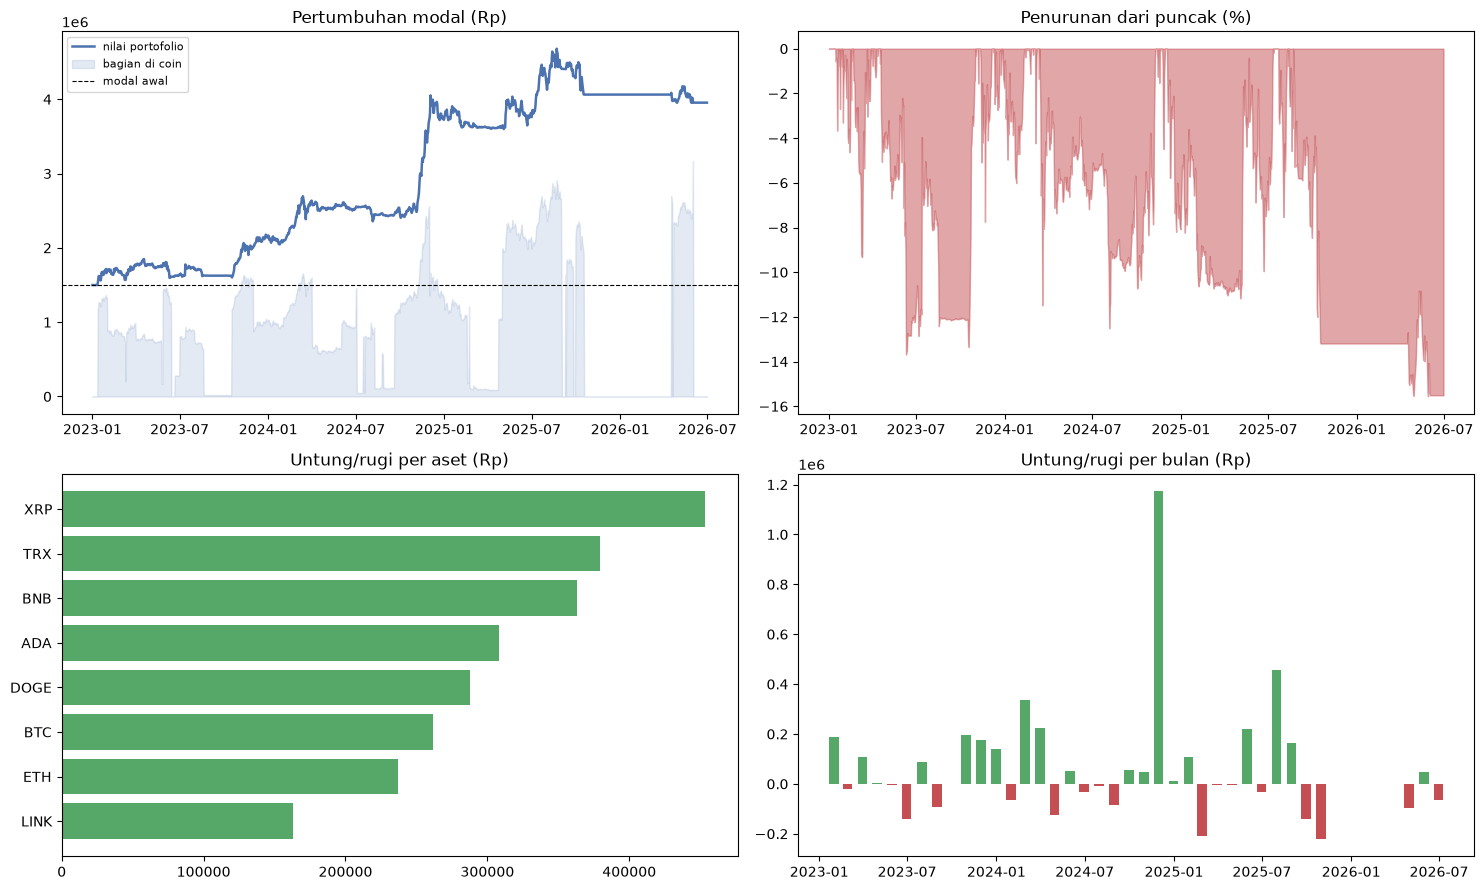

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
ax = axes[0, 0]
ax.plot(equity.index, equity, color="#4C72B0", lw=1.8, label="nilai portofolio")
ax.fill_between(values.index, 0, values.sum(axis=1), color="#4C72B0", alpha=0.15, label="bagian di coin")
ax.axhline(MODAL, color="black", lw=0.8, ls="--", label="modal awal")
ax.set_title("Pertumbuhan modal (Rp)"); ax.legend(fontsize=8)
ax = axes[0, 1]
ax.fill_between(dd.index, dd * 100, 0, color="#C44E52", alpha=0.5)
ax.set_title("Penurunan dari puncak (%)")
ax = axes[1, 0]
pc = per_coin["untung_rugi"]
ax.barh(pc.index[::-1], pc.values[::-1], color=np.where(pc.values[::-1] > 0, "#55A868", "#C44E52"))
ax.set_title("Untung/rugi per aset (Rp)")
ax = axes[1, 1]
ax.bar(mon_pnl.index, mon_pnl.values, width=20, color=np.where(mon_pnl > 0, "#55A868", "#C44E52"))
ax.set_title("Untung/rugi per bulan (Rp)")
plt.tight_layout(); plt.show()

### Eksposur dari waktu ke waktu (khas vol-targeting — tidak ada di notebook 20)

Beda dari V2-60 murni yang eksposurnya cuma dua nilai (0% atau 60%), di sini eksposur ke coin
bergerak terus-menerus antara 0-100% mengikuti volatilitas yang sedang terjadi.

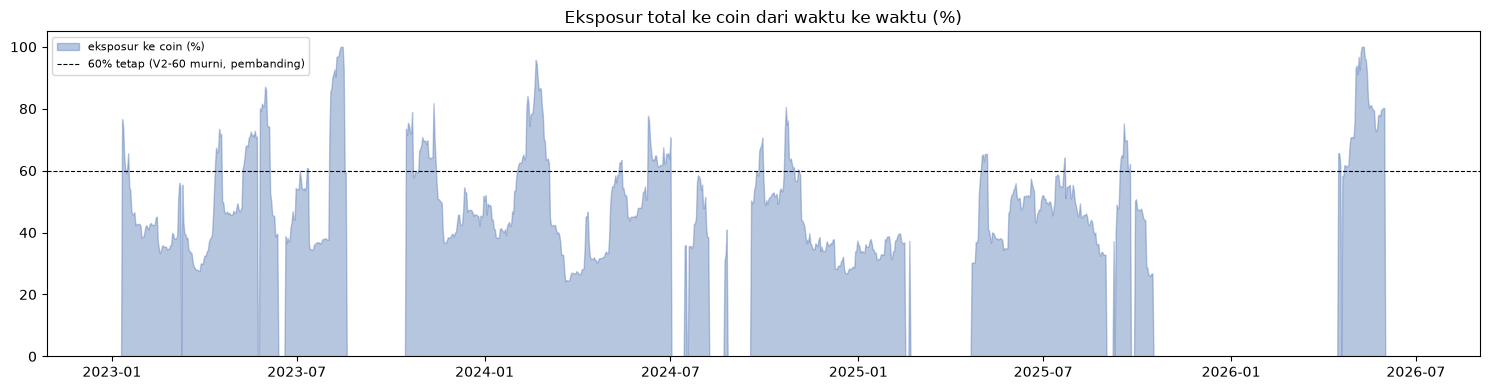

In [5]:
fig, ax = plt.subplots(figsize=(15, 4))
exp_period = (exposure * market.astype(float)).loc[PERIOD[0]:PERIOD[1]]
ax.fill_between(exp_period.index, 0, exp_period.values * 100, color="#4C72B0", alpha=0.4, label="eksposur ke coin (%)")
ax.axhline(60, color="black", lw=0.8, ls="--", label="60% tetap (V2-60 murni, pembanding)")
ax.set_ylim(0, 105); ax.set_title("Eksposur total ke coin dari waktu ke waktu (%)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. Riwayat trade per aset (masuk → keluar)

In [6]:
show = ep.copy()
show["modal_masuk"] = show["modal_masuk"].map(lambda v: f"Rp{v:,.0f}")
show["untung_rugi"] = ep["untung_rugi"].map(lambda v: f"Rp{v:+,.0f}")
show["persen"] = ep["persen"].map(lambda v: f"{v:+.1%}")
print(f"{len(ep)} trade | untung {int((ep.untung_rugi > 0).sum())} | rugi {int((ep.untung_rugi <= 0).sum())}")
show.tail(20)

107 trade | untung 40 | rugi 67


,coin,masuk,keluar,hari,modal_masuk,untung_rugi,persen,status
87,XRP,2025-09-30,2025-10-18,18,"Rp230,778","Rp-47,617",-20.6%,selesai
88,DOGE,2025-09-30,2025-10-18,18,"Rp170,441","Rp-36,806",-21.6%,selesai
89,ADA,2025-09-30,2025-10-18,18,"Rp205,793","Rp-46,864",-22.8%,selesai
90,BTC,2025-09-30,2025-10-18,18,"Rp478,429","Rp-34,367",-7.2%,selesai
91,ETH,2026-04-17,2026-04-20,3,"Rp239,784","Rp-9,374",-3.9%,selesai
92,LINK,2026-04-17,2026-04-20,3,"Rp236,030","Rp-13,965",-5.9%,selesai
93,BNB,2026-04-17,2026-04-20,3,"Rp373,082","Rp-12,662",-3.4%,selesai
94,DOGE,2026-04-17,2026-04-20,3,"Rp258,531","Rp-16,856",-6.5%,selesai
95,XRP,2026-04-17,2026-04-20,3,"Rp335,756","Rp-14,551",-4.3%,selesai
96,TRX,2026-04-17,2026-04-20,3,"Rp674,958","Rp+2,097",+0.3%,selesai


## 4. Ekspor data dashboard

In [7]:
weekly = equity.resample("W").last().index
alloc_m = values.resample("ME").mean().rename(columns=names)
alloc_m["USDT"] = cash.resample("ME").mean()
risk = market.loc[PERIOD[0]:PERIOD[1]]
blocks = []
for _, g in risk.groupby(risk.ne(risk.shift()).cumsum()):
    blocks.append({"mulai": str(g.index[0].date()), "akhir": str(g.index[-1].date()), "risk_on": bool(g.iloc[0])})
last = values.iloc[-1].rename(names)
exposure_weekly = (exposure * market.astype(float)).resample("W").mean().loc[PERIOD[0]:PERIOD[1]]
data = {
    "meta": {"strategi": "V23-VolTargeting", "modal": MODAL, "kurs": KURS, "periode": list(PERIOD),
             "aset": [names[s] for s in UNIV], "target_vol": TARGET_VOL, "vol_lookback_hari": VOL_LOOKBACK,
             "eksposur_maks": MAX_EXP, "dibuat_dari": "notebooks/25_voltargeting_portfolio_stats.ipynb"},
    "kpi": {k: (float(v) if isinstance(v, (int, float, np.floating, np.integer)) else v) for k, v in kpi.items()},
    "equity": [{"t": str(d.date()), "total": round(float(equity.loc[:d].iloc[-1])), "coin": round(float(values.sum(axis=1).loc[:d].iloc[-1])),
                "dd": round(float(dd.loc[:d].iloc[-1]) * 100, 2),
                "eksposur": round(float(exposure_weekly.loc[:d].iloc[-1]) * 100, 1)} for d in weekly],
    "alokasi_bulanan": [{"t": str(d.strftime("%Y-%m")), **{k: round(float(v)) for k, v in row.items()}} for d, row in alloc_m.iterrows()],
    "alokasi_akhir": {**{k: round(float(v)) for k, v in last.items()}, "USDT": round(float(cash.iloc[-1]))},
    "per_aset": [{"coin": c, **{k: (None if pd.isna(v) else float(v)) for k, v in row.items()}} for c, row in per_coin.iterrows()],
    "bulanan": [{"t": d.strftime("%Y-%m"), "rp": round(float(p)), "pct": round(float(r) * 100, 2)} for d, p, r in zip(mon_pnl.index, mon_pnl, mon_ret)],
    "trade": [{"coin": r.coin, "masuk": str(r.masuk), "keluar": str(r.keluar), "hari": int(r.hari),
               "modal_masuk": round(float(r.modal_masuk)), "untung_rugi": round(float(r.untung_rugi)),
               "persen": round(float(r.persen) * 100, 2), "status": r.status} for r in ep.itertuples()],
    "rezim": blocks,
}
out_path = PROJECT_ROOT / "notebooks" / "data" / "processed" / "v23_voltargeting_dashboard.json"
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(json.dumps(data, ensure_ascii=False), encoding="utf-8")
print(f"Tersimpan: {out_path.relative_to(PROJECT_ROOT)} ({out_path.stat().st_size / 1024:.0f} KB)")
print("Alokasi terakhir (Rp):", data["alokasi_akhir"])

Tersimpan: notebooks/data/processed/v23_voltargeting_dashboard.json (45 KB)
Alokasi terakhir (Rp): {'BTC': 0, 'ETH': 0, 'BNB': 0, 'XRP': 0, 'ADA': 0, 'LINK': 0, 'TRX': 0, 'DOGE': 0, 'USDT': 3954530}


## Kesimpulan (simulasi V2-60+VolTargeting, modal Rp1,5 juta, 2023-01 → 2026-06)

| | **notebook 20** (V2-60 murni) | **notebook 25** (+ vol-targeting) |
|---|---|---|
| Nilai akhir | Rp3.776.236 (+151,7%) | **Rp3.954.530 (+163,6%)** |
| Profit/tahun | +30% | **+32,0%** |
| Penurunan terbesar dari puncak | −19,2% | **−15,6%** |
| Nilai terendah | Rp1.500.000 (modal awal) | Rp1.500.000 (modal awal) — sama, tidak pernah rugi dari modal |
| Bulan untung | 45% | **47,6%** |
| Transaksi / total fee | 275 / ±Rp86.900 | 286 / **Rp75.656** (lebih kecil walau transaksi sedikit lebih banyak) |
| Trade (masuk→keluar) | 120: 45 untung, 75 rugi (win rate 38%) | 107: 40 untung, 67 rugi (win rate 37%) |
| Rata-rata untung vs rugi per trade | Rp75rb vs Rp15rb (±5×) | **Rp83rb vs Rp13rb (±6,3×)** |
| Rata-rata eksposur ke coin saat risk-on | 60% (tetap) | **49,9%** (bergerak 0-100% ikut volatilitas) |

**Menang di semua metrik yang bisa dibandingkan langsung** — sama seperti temuan notebook 23, kali
ini dilihat lewat laporan portofolio penuh (bukan cuma angka Sharpe/DD ringkas).

- **Semua 8 aset tetap menyumbang untung**: XRP Rp454rb, TRX Rp379rb, BNB Rp363rb, ADA Rp308rb,
  DOGE Rp288rb, BTC Rp262rb, ETH Rp237rb, LINK Rp163rb — urutan sedikit berbeda dari notebook 20
  (DOGE naik peringkat, LINK turun) karena eksposur yang berubah-ubah mengubah waktu masuk/keluar
  tiap coin, tapi tetap semua positif.
- **Rata-rata eksposur cuma 49,9% saat risk-on** (bukan 60% tetap) — sebagian hari eksposur ditarik
  di bawah 60% karena volatilitas sedang tinggi (lebih protektif), sebagian lain bisa sampai 100%
  saat market tenang (lebih agresif dari 60% tetap). Rata-ratanya kebetulan mendekati 60%, tapi
  *kapan* 50% itu terjadi yang membuat hasilnya lebih baik — bukan di waktu acak.
- Fee lebih kecil meski jumlah transaksi sedikit lebih banyak — karena ukuran rata-rata transaksi
  mengecil tiap kali eksposur diturunkan (porsi lebih kecil = nilai transaksi lebih kecil).
- Di akhir Juni 2026, alokasi akhir **100% USDT** — sama seperti notebook 20, filter market sedang
  risk-off di tanggal itu.

⚠️ Simulasi backtest, bukan jaminan hasil ke depan. Dashboard JSON diekspor ke
`notebooks/data/processed/v23_voltargeting_dashboard.json`, siap dipakai buat visual/dashboard
seperti punya notebook 20.